# 08A – Learning Curves & Overfitting Analysis

Enterprise notebook to evaluate model generalization using the cleaned dataset.

## Business Objective
Assess whether the bankruptcy prediction model is underfitting, overfitting, or generalizing well by analyzing learning curves.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

In [2]:
# Configuration
DATA_PATH='../data/datasets/american_bankruptcy_cleaned.csv'

df=pd.read_csv(DATA_PATH)

if 'status_label' in df.columns:
    y=df['status_label'].map({'alive':0,'failed':1})
    X=df.drop(columns=[col for col in ['status_label','company_name'] if col in df.columns])
elif 'target' in df.columns:
    y=df['target']
    X=df.drop(columns=[col for col in ['target','company_name'] if col in df.columns])
else:
    raise ValueError('Target column not found')

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y)
print(X_train.shape,X_test.shape)

(62945, 19) (15737, 19)


In [3]:
# Model configuration (matches production settings)
model=RandomForestClassifier(
    n_estimators=80,
    max_depth=12,
    random_state=42,
    class_weight='balanced',
    n_jobs=1
)

# Reduced folds/points/estimators and a training subsample keep this tractable
# on a single core while still showing the bias-variance trend clearly.
LC_SAMPLE_SIZE = 15000
if len(X_train) > LC_SAMPLE_SIZE:
    X_train_lc,_,y_train_lc,_ = train_test_split(
        X_train, y_train, train_size=LC_SAMPLE_SIZE, stratify=y_train, random_state=42
    )
else:
    X_train_lc, y_train_lc = X_train, y_train

train_sizes,train_scores,val_scores=learning_curve(
    model,
    X_train_lc,
    y_train_lc,
    cv=3,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1,1.0,5),
    n_jobs=1
)

train_mean=train_scores.mean(axis=1)
val_mean=val_scores.mean(axis=1)

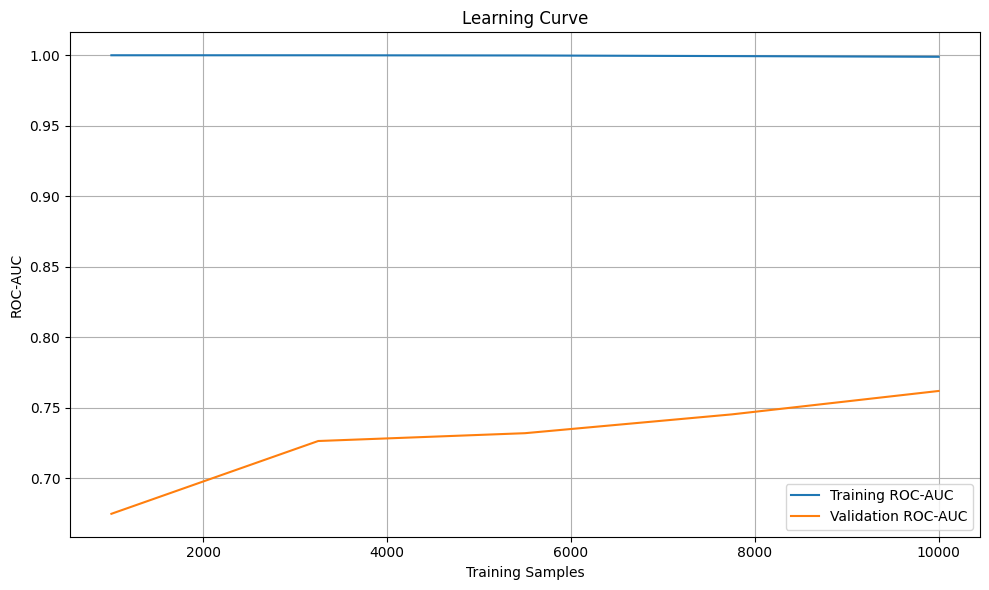

In [4]:
# Plot learning curve
plt.figure(figsize=(10,6))
plt.plot(train_sizes,train_mean,label='Training ROC-AUC')
plt.plot(train_sizes,val_mean,label='Validation ROC-AUC')
plt.xlabel('Training Samples')
plt.ylabel('ROC-AUC')
plt.title('Learning Curve')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('learning_curve.png',dpi=300)
plt.show()

In [5]:
results=pd.DataFrame({
    'Training Samples':train_sizes,
    'Training ROC_AUC':train_mean,
    'Validation ROC_AUC':val_mean,
    'Generalization Gap':train_mean-val_mean
})

results.to_csv('training_validation_scores.csv',index=False)
results

,Training Samples,Training ROC_AUC,Validation ROC_AUC,Generalization Gap
0,1000,1.000000,0.674634,0.325366
1,3250,0.999989,0.726281,0.273708
2,5500,0.999849,0.731829,0.268020
3,7750,0.999402,0.745172,0.254230
4,10000,0.998906,0.761786,0.237120


## Interpretation Guide

- Small gap + high scores → Good generalization
- Large gap → Overfitting
- Low training and validation scores → Underfitting

Review the exported CSV together with the learning curve to decide whether more data, regularization, or model tuning is required.

## Deliverables

- `learning_curve.png`
- `training_validation_scores.csv`

This notebook forms the foundation of the model validation phase and documents the model's ability to generalize to unseen data.